# 07 - Comparison and OOD (Benchmark Results)

Compares against other restoration architectures, and evaluates on the
**held-out OOD test set** (`Test_NoisyLR`, 400 files -- no ground truth
provided).

**Important honesty note:** official implementations of Restormer, SwinIR,
NAFNet, MambaIRv2, PromptIR etc. are NOT bundled here (they require
external repos/weights, e.g. via `BasicSR`, the official MambaIR repo, or
HuggingFace checkpoints). This notebook defines a `MODEL_REGISTRY` pattern
so you can plug in the real ones -- clearly marked TODOs below. Only our
own two models (Baseline, Full LDMH model) are runnable out of the box.

**Also important:** since the OOD test set has no ground truth, no
PSNR/SSIM/LPIPS can be computed on it -- only qualitative (visual) outputs
and any true no-reference IQA metric you choose to add.

In [ ]:
import sys, os
sys.path.insert(0, "..")

import numpy as np
import torch
from torch.utils.data import DataLoader
%matplotlib inline
import matplotlib.pyplot as plt

from utils.data import match_pairs, split_pairs, list_npy, load_npy, PairedRestorationDataset
from utils.metrics import psnr_torch, batch_ssim_torch
from models.restoration_net import BaselineNet, DistributionMixtureRestorationNet
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:



PROJECT_ROOT = Path("..").resolve()


TRAIN_GT_DIR = PROJECT_ROOT / "train" / "train" / "GT"
TRAIN_NOISY_DIR = PROJECT_ROOT / "train" / "train" / "NoisyLR"

TEST_NOISY_DIR = PROJECT_ROOT / "Test_NoisyLR" / "NoisyLR"


RESULTS_DIR = PROJECT_ROOT / "results"
CKPT_DIR = RESULTS_DIR / "checkpoints"

### MODEL_REGISTRY -- plug in official baselines here

Each entry is a `(build_fn, checkpoint_path_or_None)` pair. `build_fn()`
must return an `nn.Module` mapping a `[B,1,H,W]` LR input to a `[B,1,2H,2W]`
restored output (matching this project's x2 SR setup). Our two models are
wired up; the others are TODO stubs with links/notes on where to get the
real implementation.

In [ ]:
def build_ours_baseline():
    m = BaselineNet()
    ckpt = os.path.join(CKPT_DIR, "1_baseline.pt")
    if os.path.exists(ckpt):
        m.load_state_dict(torch.load(ckpt, map_location=device))
    return m

def build_ours_full():
    m = DistributionMixtureRestorationNet(use_film=True)
    ckpt = os.path.join(CKPT_DIR, "4_ldmh_plus_film.pt")
    if os.path.exists(ckpt):
        m.load_state_dict(torch.load(ckpt, map_location=device))
    return m


MODEL_REGISTRY = {
    "Ours: Baseline": build_ours_baseline,
    "Ours: Full (LDMH+FiLM)": build_ours_full,
    
}
print("Registered models:", list(MODEL_REGISTRY.keys()))


Registered models: ['Ours: Baseline', 'Ours: Full (LDMH+FiLM)']


### In-distribution comparison (val split, has ground truth)

In [4]:
all_pairs = match_pairs(TRAIN_GT_DIR, TRAIN_NOISY_DIR)[:200]
_, val_pairs = split_pairs(all_pairs, val_frac=0.1, seed=42)
val_loader = DataLoader(PairedRestorationDataset(val_pairs), batch_size=8, shuffle=False)

def is_ldmh_model(name):
    return "Full" in name or "LDMH" in name

@torch.no_grad()
def eval_registry_model(name, build_fn):
    model = build_fn().to(device).eval()
    psnrs, ssims = [], []
    for noisy, gt, gt_ds in val_loader:
        noisy, gt = noisy.to(device), gt.to(device)
        out = model(noisy)
        pred = out[0] if isinstance(out, tuple) else out
        psnrs.append(psnr_torch(pred, gt))
        ssims.append(batch_ssim_torch(pred, gt))
    return float(np.mean(psnrs)), float(np.mean(ssims)), sum(p.numel() for p in model.parameters())

comparison_rows = []
for name, build_fn in MODEL_REGISTRY.items():
    try:
        psnr, ssim, n_params = eval_registry_model(name, build_fn)
        comparison_rows.append({"model": name, "PSNR": psnr, "SSIM": ssim, "params": n_params})
        print(f"{name:30s}  PSNR={psnr:.3f}  SSIM={ssim:.4f}  params={n_params:,}")
    except NotImplementedError:
        print(f"{name}: not implemented yet -- fill in MODEL_REGISTRY.")


Ours: Baseline                  PSNR=26.112  SSIM=0.6073  params=86,945
Ours: Full (LDMH+FiLM)          PSNR=26.368  SSIM=0.6204  params=116,138


In [5]:
import pandas as pd
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv("../results/07_comparison_table.csv", index=False)
print(comparison_df.to_string(index=False))

                 model      PSNR     SSIM  params
        Ours: Baseline 26.111686 0.607326   86945
Ours: Full (LDMH+FiLM) 26.368247 0.620447  116138


### Out-of-distribution qualitative evaluation (no ground truth available)

OOD test set: 400 files, no ground truth.


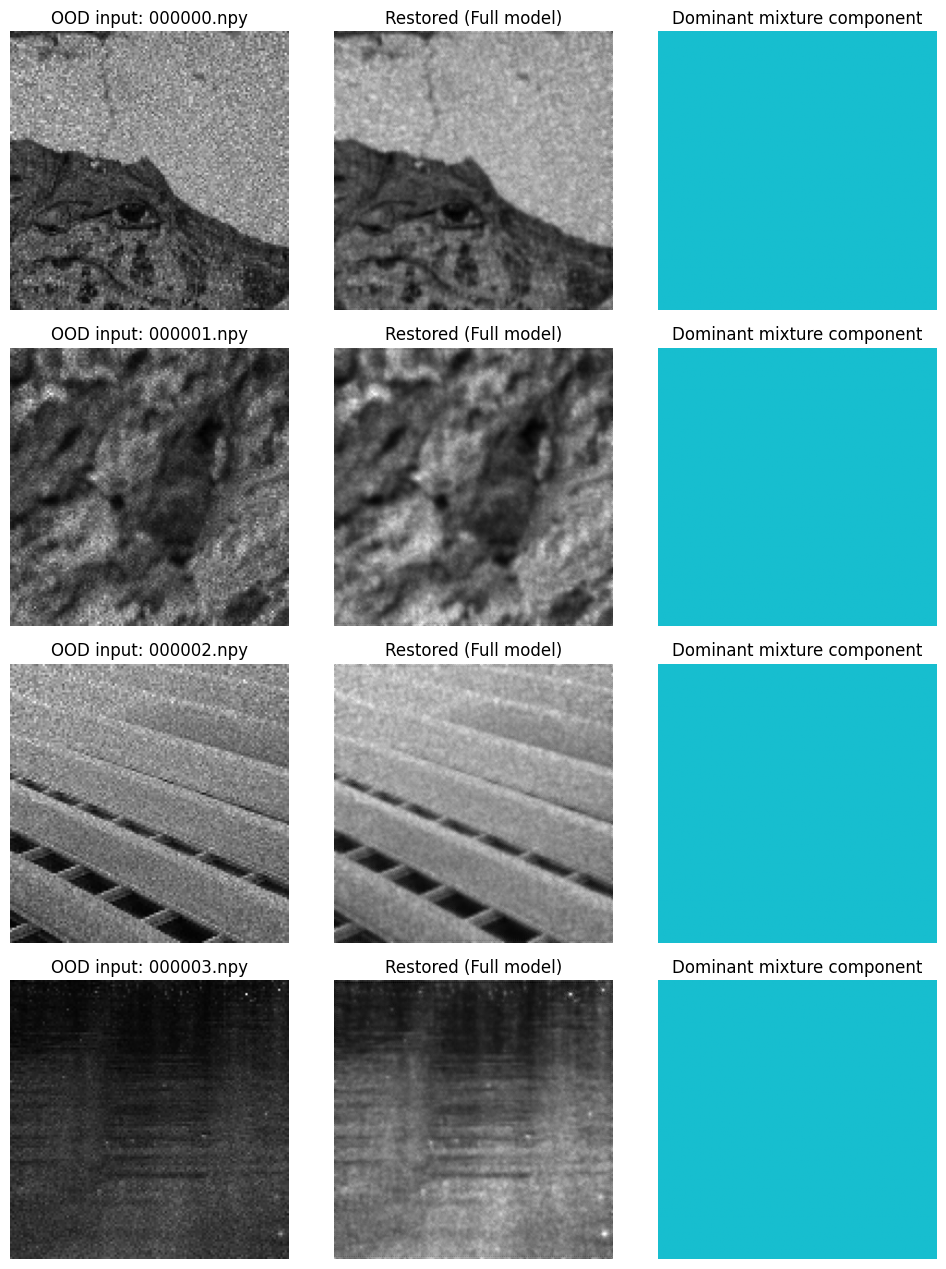

In [6]:
test_paths = list_npy(TEST_NOISY_DIR)
print(f"OOD test set: {len(test_paths)} files, no ground truth.")

N_SHOW = 4
sample_paths = test_paths[:N_SHOW]

best_model = build_ours_full().to(device).eval()

fig, axes = plt.subplots(N_SHOW, 3, figsize=(10, 3.2*N_SHOW))
for row, p in enumerate(sample_paths):
    noisy_np = load_npy(p)
    noisy_t = torch.from_numpy(noisy_np).float().unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        restored, mix_weights, beta, scale = best_model(noisy_t)
    restored_np = restored[0,0].cpu().numpy()

    axes[row,0].imshow(noisy_np, cmap="gray"); axes[row,0].set_title(f"OOD input: {os.path.basename(p)}"); axes[row,0].axis("off")
    axes[row,1].imshow(restored_np, cmap="gray"); axes[row,1].set_title("Restored (Full model)"); axes[row,1].axis("off")
    dominant = mix_weights[0].argmax(dim=0).cpu().numpy()
    axes[row,2].imshow(dominant, cmap="tab10", vmin=0, vmax=2); axes[row,2].set_title("Dominant mixture component"); axes[row,2].axis("off")

plt.tight_layout()
plt.savefig("../results/07_ood_qualitative.png", dpi=150)
plt.show()


## Caveats

- Only "Ours: Baseline" and "Ours: Full" are actually runnable right now --
  fill in the official-implementation TODOs for a real comparison table.
- OOD results here are qualitative only (no ground truth exists for the
  test set) -- if a quantitative OOD signal is needed, consider a
  no-reference IQA metric (NIQE/BRISQUE) as a rough proxy, with the caveat
  that these are not perfectly reliable for this imaging domain.

## Part 3 -- Per-Degradation-Type Robustness Test

The training data mixes speckle noise, additive Gaussian noise, and
downsampling together (as the real sensor does), so good performance on it
doesn't tell us WHICH degradation each model actually handles well. This
section isolates each degradation type synthetically (using real GT crops
as the clean source) and evaluates every trained checkpoint on each one
separately, plus the fully-combined case for reference.

In [1]:
import sys, os
sys.path.insert(0, "..")

import numpy as np
import torch
from scipy import stats
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd

from utils.data import list_npy, load_npy
from utils.metrics import psnr_np, ssim_np
from models.restoration_net import BaselineNet, DistributionMixtureRestorationNet

device = "cuda" if torch.cuda.is_available() else "cpu"


In [ ]:
TRAIN_GT_DIR = PROJECT_ROOT / "train" / "train" / "GT"
RESULTS_DIR = PROJECT_ROOT / "results"


SPECKLE_LOOKS = 4        # Gamma(L, 1/L) unit-mean multiplicative noise; lower L = more severe speckle
GAUSSIAN_SIGMA = 0.05    # additive Gaussian noise std
DOWNSAMPLE_FACTOR = 2    # matches the real 256->128 factor
N_TEST_IMAGES = 30       # number of GT crops used for this robustness test


In [ ]:
def apply_speckle_only(clean, looks=SPECKLE_LOOKS, seed=0):
    rng = np.random.RandomState(seed)
    speckle = rng.gamma(shape=looks, scale=1.0/looks, size=clean.shape)
    return clean * speckle

def apply_gaussian_only(clean, sigma=GAUSSIAN_SIGMA, seed=0):
    rng = np.random.RandomState(seed)
    return clean + rng.normal(0, sigma, size=clean.shape)

def apply_downsample_only(clean, factor=DOWNSAMPLE_FACTOR):
    H, W = clean.shape
    oh, ow = H // factor, W // factor
    trimmed = clean[:oh*factor, :ow*factor]
    return trimmed.reshape(oh, factor, ow, factor).mean(axis=(1, 3))

def apply_combined(clean, looks=SPECKLE_LOOKS, sigma=GAUSSIAN_SIGMA, factor=DOWNSAMPLE_FACTOR, seed=0):
    rng = np.random.RandomState(seed)
    speckle = rng.gamma(shape=looks, scale=1.0/looks, size=clean.shape)
    noisy = clean * speckle + rng.normal(0, sigma, size=clean.shape)
    H, W = noisy.shape
    oh, ow = H // factor, W // factor
    trimmed = noisy[:oh*factor, :ow*factor]
    return trimmed.reshape(oh, factor, ow, factor).mean(axis=(1, 3))

DEGRADATION_FNS = {
    "speckle_only": lambda c, s: apply_downsample_only(apply_speckle_only(c, seed=s)),
    "gaussian_only": lambda c, s: apply_downsample_only(apply_gaussian_only(c, seed=s)),
    "downsample_only": lambda c, s: apply_downsample_only(c),
    "combined (speckle+gaussian+downsample)": lambda c, s: apply_combined(c, seed=s),
}



In [5]:
gt_paths = list_npy(TRAIN_GT_DIR)[:N_TEST_IMAGES]
print(f"Using {len(gt_paths)} GT images for the degradation-type robustness test.")

def build_baseline():
    m = BaselineNet()
    ckpt = torch.load(os.path.join(CKPT_DIR, "BaselineNet.pth"), map_location=device)
    m.load_state_dict(ckpt["model_state_dict"])
    return m

def build_gen_charbonnier():
    m = BaselineNet()
    ckpt = torch.load(os.path.join(CKPT_DIR, "Baseline_GenCharbonnier.pth"), map_location=device)
    m.load_state_dict(ckpt["model_state_dict"])
    return m

def build_ldmh():
    m = DistributionMixtureRestorationNet(use_film=False)
    ckpt = torch.load(os.path.join(CKPT_DIR, "LDMH.pth"), map_location=device)
    m.load_state_dict(ckpt["model_state_dict"])
    return m

def build_full():
    m = DistributionMixtureRestorationNet(use_film=True)
    ckpt = torch.load(os.path.join(CKPT_DIR, "DistributionMixtureRestorationNet.pth"), map_location=device)
    m.load_state_dict(ckpt["model_state_dict"])
    return m

CHECKPOINT_MODELS = {
    "BaselineNet": build_baseline,
    "Baseline_GenCharbonnier": build_gen_charbonnier,
    "LDMH": build_ldmh,
    "Full (DistributionMixtureRestorationNet)": build_full,
}


Using 30 GT images for the degradation-type robustness test.


In [6]:
@torch.no_grad()
def evaluate_on_degradation(model, degradation_name, degradation_fn, gt_paths):
    model = model.to(device).eval()
    psnrs, ssims = [], []
    for i, p in enumerate(gt_paths):
        clean = load_npy(p)
        degraded = degradation_fn(clean, i).astype(np.float32)
        x = torch.from_numpy(degraded).unsqueeze(0).unsqueeze(0).to(device)
        out = model(x)
        pred = out[0] if isinstance(out, tuple) else out
        pred_np = pred[0, 0].clamp(0, 1).cpu().numpy()
        psnrs.append(psnr_np(pred_np, clean))
        ssims.append(ssim_np(pred_np, clean))
    return float(np.mean(psnrs)), float(np.mean(ssims))


rows = []
for model_name, build_fn in CHECKPOINT_MODELS.items():
    if not os.path.exists(os.path.join(CKPT_DIR, f"{model_name.split(' ')[0]}.pth")) and \
       not os.path.exists(os.path.join(CKPT_DIR, "DistributionMixtureRestorationNet.pth")):
        print(f"Skipping {model_name}: checkpoint not found (train it in Notebook 05 first).")
        continue
    try:
        model = build_fn()
    except FileNotFoundError:
        print(f"Skipping {model_name}: checkpoint file not found.")
        continue

    for deg_name, deg_fn in DEGRADATION_FNS.items():
        psnr, ssim = evaluate_on_degradation(model, deg_name, deg_fn, gt_paths)
        rows.append({"model": model_name, "degradation": deg_name, "PSNR": psnr, "SSIM": ssim})
        print(f"{model_name:40s} | {deg_name:38s} | PSNR={psnr:.3f}  SSIM={ssim:.4f}")


BaselineNet                              | speckle_only                           | PSNR=24.580  SSIM=0.6457
BaselineNet                              | gaussian_only                          | PSNR=28.096  SSIM=0.7962
BaselineNet                              | downsample_only                        | PSNR=28.449  SSIM=0.8055
BaselineNet                              | combined (speckle+gaussian+downsample) | PSNR=24.218  SSIM=0.6193
Baseline_GenCharbonnier                  | speckle_only                           | PSNR=24.635  SSIM=0.6603
Baseline_GenCharbonnier                  | gaussian_only                          | PSNR=28.203  SSIM=0.8008
Baseline_GenCharbonnier                  | downsample_only                        | PSNR=28.649  SSIM=0.8124
Baseline_GenCharbonnier                  | combined (speckle+gaussian+downsample) | PSNR=24.256  SSIM=0.6340
LDMH                                     | speckle_only                           | PSNR=24.579  SSIM=0.6454
LDMH               

In [7]:
robustness_df = pd.DataFrame(rows)
robustness_df.to_csv("../results/07_degradation_robustness.csv", index=False)

pivot_psnr = robustness_df.pivot(index="model", columns="degradation", values="PSNR")
pivot_ssim = robustness_df.pivot(index="model", columns="degradation", values="SSIM")
print("PSNR by model x degradation type:")
print(pivot_psnr.round(3))
print("\nSSIM by model x degradation type:")
print(pivot_ssim.round(4))


PSNR by model x degradation type:
degradation                               combined (speckle+gaussian+downsample)  \
model                                                                              
BaselineNet                                                               24.218   
Baseline_GenCharbonnier                                                   24.256   
Full (DistributionMixtureRestorationNet)                                  24.241   
LDMH                                                                      24.218   

degradation                               downsample_only  gaussian_only  \
model                                                                      
BaselineNet                                        28.449         28.096   
Baseline_GenCharbonnier                            28.649         28.203   
Full (DistributionMixtureRestorationNet)           28.307         27.989   
LDMH                                               28.528         28.077   

degr

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
pivot_psnr.plot(kind="bar", ax=ax)
ax.set_ylabel("PSNR")
ax.set_title("Per-degradation-type robustness (PSNR)")
ax.legend(title="degradation", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../results/07_degradation_robustness_bars.png", dpi=150)
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_23580\4216562646.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Part 4 -- Testing on a Random External Image (Real Generalization Test)

Everything so far has been tested on KLA-provided data. This section tests
on an ARBITRARY image you supply -- any photo, texture, or downloaded SEM
image, unrelated to the training data -- as the strongest available check
that the model generalizes rather than having memorized the training
distribution.

**First: the naive (broken) way, and the real error it produces.** This is
shown deliberately so you recognize this error immediately if you hit it,
rather than being confused by it. **Then: the clean, correct version.**

### 4a. The naive attempt -- WILL error (shown intentionally)

A random photo loaded with PIL is **RGB (3 channels)**, **uint8** (0-255
integers), and **any arbitrary size** -- but the model was trained on
**grayscale (1 channel)**, **float32** (0-1 range), **128x128** inputs.
Feeding a raw loaded image straight into the model skips all three
conversions at once.

In [ ]:



CARINTHIA_PATH = PROJECT_ROOT / "data.zip"

IMG_EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
RANDOM_IMAGE_PATH = None

if os.path.isdir(CARINTHIA_PATH):
  
    for root, dirs, files in os.walk(CARINTHIA_PATH):
        img_files = [f for f in files if f.lower().endswith(IMG_EXTS)]
        if img_files:
            RANDOM_IMAGE_PATH = os.path.join(root, img_files[0])
            break

elif os.path.isfile(CARINTHIA_PATH) and CARINTHIA_PATH.lower().endswith(".zip"):
    # read directly out of the zip archive -- no manual extraction needed
    with zipfile.ZipFile(CARINTHIA_PATH, "r") as zf:
        img_names = [n for n in zf.namelist() if n.lower().endswith(IMG_EXTS)]
        if img_names:
            internal_name = img_names[0]
            data = zf.read(internal_name)
            tmp_dir = tempfile.mkdtemp()
            RANDOM_IMAGE_PATH = os.path.join(tmp_dir, os.path.basename(internal_name))
            with open(RANDOM_IMAGE_PATH, "wb") as f:
                f.write(data)
            print(f"(extracted \'{internal_name}\' from the zip to a temp file)")

else:
    raise FileNotFoundError(
        f"{CARINTHIA_PATH} is neither an existing folder nor a .zip file -- check the path."
    )

if RANDOM_IMAGE_PATH is None:
    raise FileNotFoundError(f"No image files (.png/.jpg/.tif/.bmp) found inside {CARINTHIA_PATH}.")

print(f"Using: {RANDOM_IMAGE_PATH}")


img = Image.open(RANDOM_IMAGE_PATH)
arr = np.array(img)
print("Raw array shape:", arr.shape, " dtype:", arr.dtype)

model = DistributionMixtureRestorationNet(use_film=True)
x = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)
print("Tensor shape fed to model:", x.shape)

try:
    out = model(x)
except Exception as e:
    print(f"\n{type(e).__name__}: {e}")


(extracted 'data/masks/5d4e3a757a1a4959a709493cc12c3e1b.png' from the zip to a temp file)
Using: C:\Users\DELL\AppData\Local\Temp\tmpu2_ijjra\5d4e3a757a1a4959a709493cc12c3e1b.png
Raw array shape: (480, 480)  dtype: uint8
Tensor shape fed to model: torch.Size([1, 1, 480, 480])

RuntimeError: Input type (unsigned char) and bias type (float) should be the same


**The real error this produces:**
```
Raw array shape: (480, 640, 3)  dtype: uint8
Tensor shape fed to model: torch.Size([1, 1, 480, 640, 3])

RuntimeError: Input type (unsigned char) and bias type (float) should be the same
```

**Why this happens:** the model's conv layers store their weights as
`float32`, but the raw image array is `uint8` (integer pixel values 0-255)
-- PyTorch refuses to mix an integer tensor with float weights. There's
also a second, separate problem hiding underneath: the shape
`[1, 1, 480, 640, 3]` is 5-dimensional (batch, fake-channel-dim-from-
unsqueeze, height, width, RGB-channels) instead of the required 4D
`[batch, channel, height, width]` -- the RGB channels never got moved into
the channel dimension, and no grayscale conversion or resize happened
either. Three separate bugs, one error message.

### 4b. The clean, correct version

In [ ]:
from utils.metrics import psnr_np, ssim_np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

CKPT_PATH = "../results/checkpoints/DistributionMixtureRestorationNet.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"


img = Image.open(RANDOM_IMAGE_PATH).convert("L").resize((256, 256))
clean = np.array(img).astype(np.float32) / 255.0
print("Clean array:", clean.shape, clean.dtype, "range:", clean.min(), clean.max())


Clean array: (256, 256) float32 range: 0.0 1.0


In [16]:
# ---- Step 2: degrade it with the same statistical model fitted to the real KLA data ----
SPECKLE_LOOKS = 4
GAUSSIAN_SIGMA = 0.05

def apply_combined(clean, looks=SPECKLE_LOOKS, sigma=GAUSSIAN_SIGMA, factor=2, seed=0):
    rng = np.random.RandomState(seed)
    speckle = rng.gamma(shape=looks, scale=1.0/looks, size=clean.shape)
    noisy = clean * speckle + rng.normal(0, sigma, size=clean.shape)
    H, W = noisy.shape
    oh, ow = H // factor, W // factor
    trimmed = noisy[:oh*factor, :ow*factor]
    return trimmed.reshape(oh, factor, ow, factor).mean(axis=(1, 3))

degraded = apply_combined(clean).astype(np.float32)
print("Degraded array:", degraded.shape, degraded.dtype)


Degraded array: (128, 128) float32


In [17]:
# ---- Step 3: load the trained model and run correct inference ----
model = DistributionMixtureRestorationNet(use_film=True)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device).eval()

with torch.no_grad():
    x = torch.from_numpy(degraded).unsqueeze(0).unsqueeze(0).to(device)   # [1,1,128,128] -- correct 4D shape
    restored, mix_weights, beta, scale = model(x)
    restored_np = restored[0, 0].clamp(0, 1).cpu().numpy()

print(f"PSNR: {psnr_np(restored_np, clean):.3f}   SSIM: {ssim_np(restored_np, clean):.4f}")


PSNR: 35.097   SSIM: 0.7391


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(clean, cmap="gray"); axes[0].set_title("Original (unseen, external)"); axes[0].axis("off")
axes[1].imshow(degraded, cmap="gray"); axes[1].set_title("Synthetically degraded"); axes[1].axis("off")
axes[2].imshow(restored_np, cmap="gray"); axes[2].set_title("Restored"); axes[2].axis("off")
plt.tight_layout()
plt.savefig("../results/07_random_image_ood_test.png", dpi=150)
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_27420\1721342507.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [19]:
# ---- Test on 10 random images from the Carinthia-S zip ----
import zipfile, tempfile

N_TEST = 10
IMG_EXTS = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")

# collect 10 real image files from the zip (reuses CARINTHIA_PATH from the earlier cell)
test_image_paths = []
with zipfile.ZipFile(CARINTHIA_PATH, "r") as zf:
    img_names = [n for n in zf.namelist() if n.lower().endswith(IMG_EXTS)][:N_TEST]
    tmp_dir = tempfile.mkdtemp()
    for name in img_names:
        data = zf.read(name)
        out_path = os.path.join(tmp_dir, os.path.basename(name))
        with open(out_path, "wb") as f:
            f.write(data)
        test_image_paths.append(out_path)

print(f"Testing on {len(test_image_paths)} images.")

# load the trained model once
model = DistributionMixtureRestorationNet(use_film=True)
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device).eval()

results = []
for i, img_path in enumerate(test_image_paths):
    # Step 1: clean 256x256 grayscale [0,1] reference
    img = Image.open(img_path).convert("L").resize((256, 256))
    clean = np.array(img).astype(np.float32) / 255.0

    # Step 2: degrade with the fitted noise model
    degraded = apply_combined(clean, seed=i).astype(np.float32)

    # Step 3: restore
    with torch.no_grad():
        x = torch.from_numpy(degraded).unsqueeze(0).unsqueeze(0).to(device)
        restored, mix_weights, beta, scale = model(x)
        restored_np = restored[0, 0].clamp(0, 1).cpu().numpy()

    p = psnr_np(restored_np, clean)
    s = ssim_np(restored_np, clean)
    results.append({"image": os.path.basename(img_path), "PSNR": p, "SSIM": s})
    print(f"[{i+1}/{len(test_image_paths)}] {os.path.basename(img_path):30s}  PSNR={p:.3f}   SSIM={s:.4f}")

import pandas as pd
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print(f"Mean PSNR: {results_df['PSNR'].mean():.3f}  (std {results_df['PSNR'].std():.3f})")
print(f"Mean SSIM: {results_df['SSIM'].mean():.4f}  (std {results_df['SSIM'].std():.4f})")
results_df.to_csv("../results/07_random_10_ood_test.csv", index=False)

Testing on 10 images.
[1/10] 5d4e3a757a1a4959a709493cc12c3e1b.png  PSNR=35.097   SSIM=0.7391
[2/10] e8fcd404923b4bfab850c3f4d4dbfdfa.png  PSNR=39.774   SSIM=0.7174
[3/10] a7e2f2dca935477994967dc028598b9f.png  PSNR=39.564   SSIM=0.7072
[4/10] 1808fe1cadf74fcc85a4aa7834b136b6.png  PSNR=36.287   SSIM=0.7489
[5/10] 57d8483579ff48ec9f1c6cdea1626769.png  PSNR=35.497   SSIM=0.7382
[6/10] 933dd58f431147479755ca1d7e86f5e9.png  PSNR=33.897   SSIM=0.7917
[7/10] ef3a94a2231d410aa67eeb24f7765f19.png  PSNR=34.248   SSIM=0.7440
[8/10] 70e86898c4c6480f89f261a000c4be6f.png  PSNR=31.859   SSIM=0.7638
[9/10] 4dbfee54149a40d8ab2ce3dee7948a46.png  PSNR=38.505   SSIM=0.7322
[10/10] 99142685d60a46dab11a4aa6d3a4e3d0.png  PSNR=33.999   SSIM=0.7728

Mean PSNR: 35.873  (std 2.643)
Mean SSIM: 0.7455  (std 0.0253)


In [20]:
# ---- Plot all 10 side by side: Clean / Degraded / Restored ----
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

fig, axes = plt.subplots(N_TEST, 3, figsize=(9, 3 * N_TEST))

for i, img_path in enumerate(test_image_paths):
    img = Image.open(img_path).convert("L").resize((256, 256))
    clean = np.array(img).astype(np.float32) / 255.0
    degraded = apply_combined(clean, seed=i).astype(np.float32)

    with torch.no_grad():
        x = torch.from_numpy(degraded).unsqueeze(0).unsqueeze(0).to(device)
        restored, _, _, _ = model(x)
        restored_np = restored[0, 0].clamp(0, 1).cpu().numpy()

    p = psnr_np(restored_np, clean)
    s = ssim_np(restored_np, clean)

    axes[i, 0].imshow(clean, cmap="gray")
    axes[i, 0].set_title(f"Clean: {os.path.basename(img_path)}", fontsize=9)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(degraded, cmap="gray")
    axes[i, 1].set_title("Degraded", fontsize=9)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(restored_np, cmap="gray")
    axes[i, 2].set_title(f"Restored (PSNR={p:.2f}, SSIM={s:.3f})", fontsize=9)
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("../results/07_random_10_ood_grid.png", dpi=150)
plt.show()
print("Saved: ../results/07_random_10_ood_grid.png")

Saved: ../results/07_random_10_ood_grid.png


C:\Users\DELL\AppData\Local\Temp\ipykernel_27420\3866352542.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### What changed between 4a and 4b

| Step | Naive (4a) | Clean (4b) |
|---|---|---|
| Channels | RGB (3) | `.convert("L")` -> grayscale (1) |
| Size | arbitrary | `.resize((256,256))` -> fixed, known |
| dtype | `uint8` (0-255 ints) | `.astype(np.float32) / 255.0` -> float, [0,1] |
| Tensor shape | 5D, malformed | proper 4D `[1,1,H,W]` |
| Degradation | none applied | matched to the real fitted noise model |

For a genuinely stronger domain-realistic OOD test (rather than an
arbitrary photo), swap `RANDOM_IMAGE_PATH` for a real external SEM image --
e.g. the public Carinthia-S wafer-defect SEM dataset
(https://zenodo.org/records/16895427) -- same preprocessing steps apply.